In [28]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [4]:
df=pd.read_csv("/content/POWER_Point_Daily_20150101_20260622_028d98N_077d70E_LST.csv",skiprows=15)

In [5]:
df.head()

,YEAR,DOY,T2M,WS2M_MAX,WD2M,RH2M,QV2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN
0,2015,1,15.54,1.93,321.9,41.23,4.50,0.00,7.78
1,2015,2,16.40,2.60,183.8,52.99,6.11,4.10,3.06
2,2015,3,14.30,1.62,307.7,75.05,7.56,11.06,4.97
3,2015,4,13.26,4.10,298.1,62.61,5.62,0.04,7.59
4,2015,5,12.96,6.23,291.1,43.38,3.79,0.03,12.95


In [7]:
df=df.replace(-999,np.nan)
df=df.replace(-999.0,np.nan)

df.isna().sum()

,0
YEAR,0
DOY,0
T2M,3
WS2M_MAX,3
WD2M,3
RH2M,3
QV2M,3
PRECTOTCORR,3
ALLSKY_SFC_SW_DWN,8


In [8]:
df=df.interpolate()

In [9]:
df["date"]=pd.to_datetime(df["YEAR"].astype(str),format="%Y")+pd.to_timedelta(df["DOY"]-1,unit="D")

In [10]:
df["date"].head()

,date
0,2015-01-01
1,2015-01-02
2,2015-01-03
3,2015-01-04
4,2015-01-05


In [11]:
df["doy_sin"]=np.sin(2*np.pi*df["DOY"]/365)
df["doy_cos"]=np.cos(2*np.pi*df["DOY"]/365)

In [12]:
df["WD2M_sin"] = np.sin(
    np.radians(df["WD2M"])
)

df["WD2M_cos"] = np.cos(
    np.radians(df["WD2M"])
)

In [13]:
df = df.drop(columns=["WD2M"])

In [14]:
df = df.sort_values("date")
df = df.reset_index(drop=True)

In [18]:
features = [
    "T2M",
    "WS2M_MAX",
    "RH2M",
    "QV2M",
    "PRECTOTCORR",
    "ALLSKY_SFC_SW_DWN",
    "WD2M_sin",
    "WD2M_cos",
    "doy_sin",
    "doy_cos"
]

In [19]:
split = int(len(df)*0.8)

train_df = df[:split]
test_df = df[split:]

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_df[features]
)

test_scaled = scaler.transform(
    test_df[features]
)

In [21]:
WINDOW_SIZE = 30
HORIZON = 7

In [22]:
import numpy as np

WINDOW_SIZE = 30
HORIZON = 7

def make_windows(data, window_size, horizon):
    X = []
    y = []

    for i in range(len(data) - window_size - horizon + 1):

        X.append(
            data[i:i + window_size]
        )

        y.append(
            data[
                i + window_size :
                i + window_size + horizon,
                0  # T2M column
            ]
        )

    return np.array(X), np.array(y)

In [23]:
X_train, y_train = make_windows(
    train_scaled,
    WINDOW_SIZE,
    HORIZON
)

X_test, y_test = make_windows(
    test_scaled,
    WINDOW_SIZE,
    HORIZON
)

In [24]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(3316, 30, 10)
(3316, 7)
(803, 30, 10)
(803, 7)


In [25]:
print(X_train[0].shape)
print(y_train[0])

(30, 10)
[0.16380894 0.23668096 0.26362523 0.25627679 0.21861604 0.19595836
 0.2134109 ]


In [27]:
print(X_train.dtype)
print(y_train.dtype)

float64
float64


In [29]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30, 10)),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(7)
])

model.compile(
    loss="mae",
    optimizer="adam",
    metrics=["mae"]
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32
)

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1054 - mae: 0.1054 - val_loss: 0.0476 - val_mae: 0.0476
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0478 - mae: 0.0478 - val_loss: 0.0446 - val_mae: 0.0446
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0462 - mae: 0.0462 - val_loss: 0.0442 - val_mae: 0.0442
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0455 - mae: 0.0455 - val_loss: 0.0433 - val_mae: 0.0433
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0450 - mae: 0.0450 - val_loss: 0.0433 - val_mae: 0.0433
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0446 - mae: 0.0446 - val_loss: 0.0430 - val_mae: 0.0430
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0444 - mae: 0.0444 - val_loss: 0.0429 - val_mae: 0.0429
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0440 - mae: 0.0440 - val_loss: 0.0425 - val_mae: 0.0425
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/

In [31]:
preds = model.predict(X_test)

print(preds.shape)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
(803, 7)


In [32]:
print(preds[0])

[0.68253744 0.7045717  0.71101964 0.71494144 0.7108885  0.7414935
 0.7467727 ]


In [37]:
t2m_min = scaler.data_min_[0]
t2m_max = scaler.data_max_[0]

preds_actual = preds * (t2m_max - t2m_min) + t2m_min
y_actual = y_test * (t2m_max - t2m_min) + t2m_min

In [38]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    y_actual.flatten(),
    preds_actual.flatten()
)

print("MAE:", mae, "°C")

MAE: 1.422491441116326 °C


In [39]:
for day in range(7):
    mae = mean_absolute_error(
        y_actual[:, day],
        preds_actual[:, day]
    )

    print(f"Day {day+1}: {mae:.2f} °C")

Day 1: 0.86 °C
Day 2: 1.21 °C
Day 3: 1.40 °C
Day 4: 1.51 °C
Day 5: 1.62 °C
Day 6: 1.62 °C
Day 7: 1.73 °C


In [40]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_actual.flatten(),
    preds_actual.flatten()
)

rmse = mean_squared_error(
    y_actual.flatten(),
    preds_actual.flatten()
) ** 0.5

r2 = r2_score(
    y_actual.flatten(),
    preds_actual.flatten()
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.422491441116326
RMSE: 1.8705670773018224
R²: 0.9398462758490078


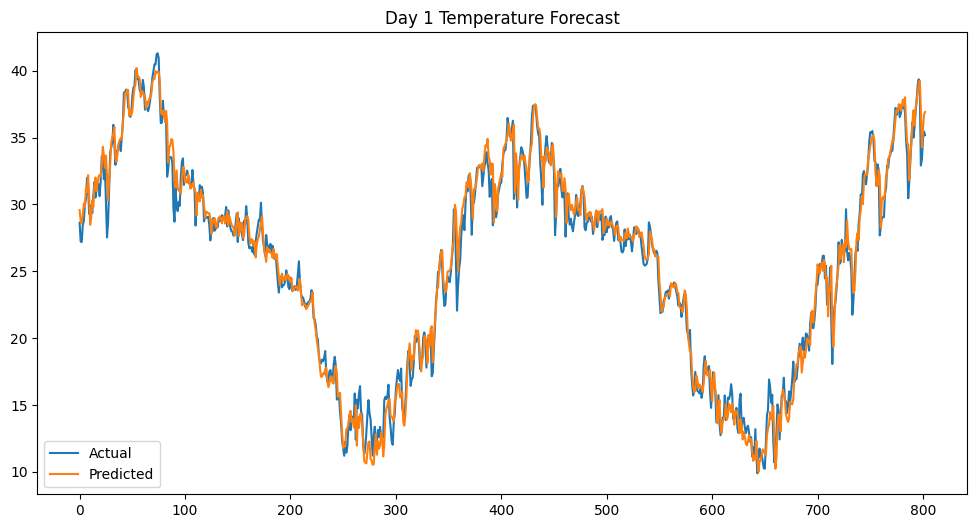

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_actual[:,0],
    label="Actual"
)

plt.plot(
    preds_actual[:,0],
    label="Predicted"
)

plt.legend()
plt.title("Day 1 Temperature Forecast")
plt.show()

In [42]:
model.save("temperature_model.keras")

In [43]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [44]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,535 (252.09 KB)

 Trainable params: 21,511 (84.03 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,024 (168.07 KB)